In [48]:
# Data handling and manipulation library
import pandas as pd

# Library for numerical operations in Python
import numpy as np

# Visualizations library
import matplotlib.pyplot as plt

# Exploratory visualizations library
import seaborn as sns

# Statistical functions library
from scipy import stats

# ml libraries
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo, Rotator
from sklearn.decomposition import PCA

import os

from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)


In [49]:
# === 2) Load raw CSVs (semicolon; Danish chars) ===
# If your files are elsewhere, adjust the paths below.
t2d  = pd.read_csv("../files/T2D.csv", sep=";", encoding="latin-1")
mob  = pd.read_csv("../files/Morbidly_Obese.csv", sep=";", encoding="latin-1")
ltd  = pd.read_csv("../files/Longterm_Disease.csv", sep=";", encoding="latin-1")
fbc  = pd.read_csv("../files/Fraction_Blood_Clot.csv", sep=";", encoding="latin-1")
edu  = pd.read_csv("../files/Education_Long.csv", sep=";", encoding="latin-1")
who  = pd.read_csv("../files/WHO_Minimum_Physical_Activity.csv", sep=";", encoding="latin-1")
life = pd.read_csv("../files/Life_Expectancy.csv", sep=";", encoding="latin-1")
absn = pd.read_csv("../files/Absence.csv", sep=";", encoding="latin-1")

# Quick inspect (as in exercises)
print(t2d.shape);  print(t2d.head(3))

(60, 5)
   brick_nr          brick     patients  population patients_per_1000
0       101       Bornholm  2248,978472       33046       68,05599685
1       102         Amager  6136,772115      154254       39,78355255
2       103  Nørrebro/City  3019,148357       88293       34,19465141


In [50]:
# === 3) Standardize column names (lowercase, strip) ===
for df in [t2d, mob, ltd, fbc, edu, who, life, absn]:
    df.columns = [c.strip().lower() for c in df.columns]

# Ensure key 'brick_nr' is numeric (Int64) for safe merges
for df in [t2d, mob, ltd, fbc, edu, who, life, absn]:
    if "brick_nr" in df.columns:
        df["brick_nr"] = pd.to_numeric(df["brick_nr"], errors="coerce").astype("Int64")

In [51]:
# === 4) Add dataset suffixes so column origins are clear ===
t2d = t2d.rename(columns={k: f"{k}_t2d" for k in t2d.columns if k not in ["brick_nr","brick"]})
mob = mob.rename(columns={k: f"{k}_morbidly_obese" for k in mob.columns if k not in ["brick_nr","brick"]})
ltd = ltd.rename(columns={k: f"{k}_longterm_disease" for k in ltd.columns if k not in ["brick_nr","brick"]})
fbc = fbc.rename(columns={k: f"{k}_fraction_blood_clot" for k in fbc.columns if k not in ["brick_nr","brick"]})
edu = edu.rename(columns={k: f"{k}_education_long" for k in edu.columns if k not in ["brick_nr","brick"]})
who = who.rename(columns={k: f"{k}_who_minimum_physical_activity" for k in who.columns if k not in ["brick_nr","brick"]})
life = life.rename(columns={k: f"{k}_life_expectancy" for k in life.columns if k not in ["brick_nr","brick"]})
absn = absn.rename(columns={k: f"{k}_absence" for k in absn.columns if k not in ["brick_nr","brick"]})

In [52]:
# === 5) Merge (step-by-step, as in class) ===
merged = t2d.merge(mob,  on=["brick_nr","brick"], how="left")
merged = merged.merge(ltd, on=["brick_nr","brick"], how="left")
merged = merged.merge(fbc, on=["brick_nr","brick"], how="left")
merged = merged.merge(edu, on=["brick_nr","brick"], how="left")
merged = merged.merge(who, on=["brick_nr","brick"], how="left")
merged = merged.merge(life,on=["brick_nr","brick"], how="left")
merged = merged.merge(absn,on=["brick_nr","brick"], how="left")

print(merged.shape)
merged.head()

(60, 15)


,brick_nr,brick,patients_t2d,population_t2d,patients_per_1000_t2d,andel_morbidly_obese,anddel_longterm_disease,andel med blodprop i hjertet_fraction_blood_clot,antal_education_long,brick_navn_education_long,population_education_long,value_per_1000_education_long,andel_who_minimum_physical_activity,år_life_expectancy,fravær_absence
0,101,Bornholm,"2248,978472",33046,"68,05599685","0,1755","0,4065","0,0205","6035,258672188186",Bornholm,33046,"182,6320484230523","0,302","77,1905","6,2865"
1,102,Amager,"6136,772115",154254,"39,78355255","0,13033333333333333","0,32666666666666666","0,009000000000000001","64810,874711589306",Amager,154254,"420,15684981646706","0,24333333333333332","79,96766666666666","5,747333333333334"
2,103,Nørrebro/City,"3019,148357",88293,"34,19465141","0,1075",NaN,"0,0075","44280,90932139913",Nørrebro/City,88293,"501,5223100517496","0,2215","79,283","5,499499999999999"
3,104,Vesterbro/Christianshavn,"3387,602593",103052,"32,87274961","0,1","0,3075","0,008","49553,41956356552",Vesterbro/Christianshavn,103052,"480,85839734857666","0,225","80,05","5,58"
4,105,Frederiksberg,"3574,931136",105260,"33,96286468","0,104","0,306","0,008","52262,04744646349",Frederiksberg,105260,"496,5043458717793","0,223","79,6455","5,5375"


In [53]:
# === 6) Cleaning (simple, exercise-style) ===
# Replace spaces, thousands '.', and decimal ',' -> '.' for all non-key columns, then to_numeric

for col in merged.columns:
    if col in ["brick_nr","brick"]:
        continue
    merged[col] = (
        merged[col]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace(".", "", regex=False)   # remove thousands dot if present
        .str.replace(",", ".", regex=False)  # decimal comma -> dot
    )
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

# Derived prevalence if missing
if "patients_per_1000_t2d" not in merged.columns and {"patients_t2d","population_t2d"}.issubset(merged.columns):
    merged["patients_per_1000_t2d"] = (merged["patients_t2d"] / merged["population_t2d"]) * 1000

print("NA per column (top):")
print(merged.isna().sum().sort_values(ascending=False).head(15))
print("\nDuplicates on (brick_nr, brick):", merged.duplicated(subset=["brick_nr","brick"]).sum())

NA per column (top):
brick_navn_education_long                           60
anddel_longterm_disease                             15
brick_nr                                             0
brick                                                0
patients_t2d                                         0
population_t2d                                       0
patients_per_1000_t2d                                0
andel_morbidly_obese                                 0
andel med blodprop i hjertet_fraction_blood_clot     0
antal_education_long                                 0
population_education_long                            0
value_per_1000_education_long                        0
andel_who_minimum_physical_activity                  0
år_life_expectancy                                   0
fravær_absence                                       0
dtype: int64

Duplicates on (brick_nr, brick): 0


In [54]:
# === 7) Focus on relevant columns and rename to English ===
focus_cols = [
    "brick_nr", "brick",
    "patients_t2d",
    "patients_per_1000_t2d",
    "andel_morbidly_obese",
    "anddel_longterm_disease",
    "andel med blodprop i hjertet_fraction_blood_clot",
    "value_per_1000_education_long",
    "andel_who_minimum_physical_activity",
    "år_life_expectancy",
    "fravær_absence"
]

df = merged[focus_cols].copy()

rename_map = {
    "brick_nr": "brick_id",
    "brick": "brick_name",
    "patients_t2d": "t2d_patients",
    "patients_per_1000_t2d": "t2d_prevalence_per_1000",
    "andel_morbidly_obese": "morbid_obesity_share",
    "anddel_longterm_disease": "longterm_disease_share",
    "andel med blodprop i hjertet_fraction_blood_clot": "fraction_blood_clot",
    "value_per_1000_education_long": "higher_education_per_1000",
    "andel_who_minimum_physical_activity": "minimum_physical_activity",
    "år_life_expectancy": "life_expectancy_years",
    "fravær_absence": "work_absence_rate"
}
df = df.rename(columns=rename_map)

# Ensure numeric types (in case)
for col in df.columns:
    if col in ["brick_id","brick_name"]:
        continue
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.head())

   brick_id                brick_name  t2d_patients  t2d_prevalence_per_1000  morbid_obesity_share  longterm_disease_share  fraction_blood_clot  higher_education_per_1000  minimum_physical_activity  \
0       101                  Bornholm   2248.978472                68.055997              0.175500                0.406500               0.0205                 182.632048                   0.302000   
1       102                    Amager   6136.772115                39.783553              0.130333                0.326667               0.0090                 420.156850                   0.243333   
2       103             Nørrebro/City   3019.148357                34.194651              0.107500                     NaN               0.0075                 501.522310                   0.221500   
3       104  Vesterbro/Christianshavn   3387.602593                32.872750              0.100000                0.307500               0.0080                 480.858397                   0.22500

In [55]:
# === 8) Save the cleaned dataset to CSV for factor analysis ===
output_path = "../files/merged_factor_analysis.csv"
df.to_csv(output_path, index=False)

print(f"✓ Dataset saved to: {output_path}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values per column:")
print(df.isna().sum())

✓ Dataset saved to: ../files/merged_factor_analysis.csv
Shape: (60, 11)
Columns: ['brick_id', 'brick_name', 't2d_patients', 't2d_prevalence_per_1000', 'morbid_obesity_share', 'longterm_disease_share', 'fraction_blood_clot', 'higher_education_per_1000', 'minimum_physical_activity', 'life_expectancy_years', 'work_absence_rate']

Missing values per column:
brick_id                      0
brick_name                    0
t2d_patients                  0
t2d_prevalence_per_1000       0
morbid_obesity_share          0
longterm_disease_share       15
fraction_blood_clot           0
higher_education_per_1000     0
minimum_physical_activity     0
life_expectancy_years         0
work_absence_rate             0
dtype: int64


In [56]:
# === 8) Descriptive statistics ===
numeric_cols = [c for c in df.columns if c not in ["brick_id","brick_name"]]
print(df[numeric_cols].describe().T)

# Top bricks by prevalence and by absolute patients
print("\nTop 10 bricks by T2D prevalence per 1000:")
display(df.nlargest(10, "t2d_prevalence_per_1000")[["brick_name","t2d_prevalence_per_1000","t2d_patients"]])

print("\nTop 10 bricks by number of T2D patients:")
display(df.nlargest(10, "t2d_patients")[["brick_name","t2d_patients","t2d_prevalence_per_1000"]])

                           count         mean          std          min          25%          50%          75%          max
t2d_patients                60.0  4007.828302  1332.750880  1979.051798  3168.119739  3773.611862  4718.673252  7612.328605
t2d_prevalence_per_1000     60.0    53.844056    10.598198    32.713481    47.354050    55.564150    60.342694    79.307688
morbid_obesity_share        60.0     0.177191     0.037982     0.094500     0.163446     0.186602     0.206083     0.231143
longterm_disease_share      45.0     0.363726     0.025547     0.305000     0.354000     0.362167     0.378400     0.421000
fraction_blood_clot         60.0     0.012851     0.003015     0.005500     0.011575     0.013268     0.014687     0.020500
higher_education_per_1000   60.0   275.280640    95.263443   143.789559   211.411794   249.634373   301.914606   517.512247
minimum_physical_activity   60.0     0.297434     0.036065     0.220000     0.282800     0.300667     0.323471     0.359250
life_exp

,brick_name,t2d_prevalence_per_1000,t2d_patients
24,Lolland,79.307688,3765.766956
33,Tønder,71.006532,2043.070950
23,Falster,69.206581,3213.192353
15,Tåstrup,68.579928,6179.188718
0,Bornholm,68.055997,2248.978472
18,Kalundborg,67.910043,7027.738707
31,Sønderborg,65.031448,3907.674682
32,Aabenraa,64.662615,3936.207344
55,Thisted,64.225625,3336.906572
22,Vordingborg,64.034578,3873.451601



Top 10 bricks by number of T2D patients:


,brick_name,t2d_patients,t2d_prevalence_per_1000
5,Glostrup,7612.328605,63.024313
43,Ydre Århus,7242.629748,39.307856
18,Kalundborg,7027.738707,67.910043
50,Randers,6259.278154,53.040235
15,Tåstrup,6179.188718,68.579928
1,Amager,6136.772115,39.783553
16,Køge Bugt,5959.958458,56.298255
13,Frederikssund,5535.080499,57.224330
45,Herning,5502.937133,54.019212
36,Kolding,5447.790987,52.871155


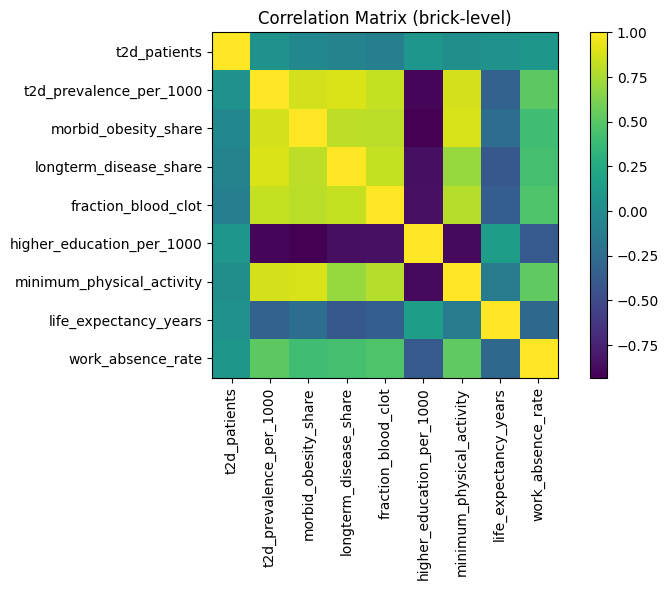


Correlation with T2D prevalence per 1000 (sorted):
t2d_prevalence_per_1000      1.000000
longterm_disease_share       0.889425
minimum_physical_activity    0.872541
morbid_obesity_share         0.864901
fraction_blood_clot          0.828753
work_absence_rate            0.511937
t2d_patients                 0.050995
life_expectancy_years       -0.320282
higher_education_per_1000   -0.894309
Name: t2d_prevalence_per_1000, dtype: float64


In [57]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,6))
im = plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Matrix (brick-level)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(len(numeric_cols)), labels=numeric_cols, rotation=90)
plt.yticks(np.arange(len(numeric_cols)), labels=numeric_cols)
plt.tight_layout()
plt.show()

# Also print correlations with our main KPI (prevalence)
if "t2d_prevalence_per_1000" in corr.columns:
    print("\nCorrelation with T2D prevalence per 1000 (sorted):")
    print(corr["t2d_prevalence_per_1000"].sort_values(ascending=False))

In [58]:
# R correlation matrix (for Factor Analysis)

satData = df
numeric_data = satData.select_dtypes(include=["number"])
satMatrix = numeric_data.corr()
satMatrix_rounded = satMatrix.round(2)
print(satMatrix_rounded)

                           brick_id  t2d_patients  t2d_prevalence_per_1000  morbid_obesity_share  longterm_disease_share  fraction_blood_clot  higher_education_per_1000  minimum_physical_activity  \
brick_id                       1.00         -0.18                     0.16                  0.42                    0.29                 0.29                      -0.46                       0.19   
t2d_patients                  -0.18          1.00                     0.05                 -0.03                   -0.07                -0.09                       0.08                       0.02   
t2d_prevalence_per_1000        0.16          0.05                     1.00                  0.86                    0.89                 0.83                      -0.89                       0.87   
morbid_obesity_share           0.42         -0.03                     0.86                  1.00                    0.80                 0.80                      -0.93                       0.88   
longt

In [59]:
# finding the factors that has the highest correlations

# Correlation matrix
corr_matrix = numeric_data.corr().round(2)

# Convert to long format (pairs of variables)
corr_pairs = corr_matrix.unstack()

# Remove self-correlations (always = 1.0)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Drop duplicate pairs (A,B) vs (B,A)
corr_pairs = corr_pairs.drop_duplicates().sort_values(ascending=False)

# Show top 10 highest correlations
print(corr_pairs.head(10))

t2d_prevalence_per_1000    longterm_disease_share       0.89
morbid_obesity_share       minimum_physical_activity    0.88
t2d_prevalence_per_1000    minimum_physical_activity    0.87
                           morbid_obesity_share         0.86
                           fraction_blood_clot          0.83
morbid_obesity_share       longterm_disease_share       0.80
fraction_blood_clot        minimum_physical_activity    0.78
longterm_disease_share     minimum_physical_activity    0.70
minimum_physical_activity  work_absence_rate            0.53
t2d_prevalence_per_1000    work_absence_rate            0.51
dtype: float64


In [60]:
# KMO Test - requires only numeric columns
numeric_cols = [c for c in df.columns if c not in ["brick_id","brick_name"]]
df_clean = df[numeric_cols].dropna()

kmo_all, kmo_model = calculate_kmo(df_clean)
kmo_model

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/factor_analyzer/utils.py:244: UserWarning:

The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.



np.float64(0.7831211950668561)

In [61]:
df_clean.head()

,t2d_patients,t2d_prevalence_per_1000,morbid_obesity_share,longterm_disease_share,fraction_blood_clot,higher_education_per_1000,minimum_physical_activity,life_expectancy_years,work_absence_rate
0,2248.978472,68.055997,0.175500,0.406500,0.0205,182.632048,0.302000,77.190500,6.286500
1,6136.772115,39.783553,0.130333,0.326667,0.0090,420.156850,0.243333,79.967667,5.747333
3,3387.602593,32.872750,0.100000,0.307500,0.0080,480.858397,0.225000,80.050000,5.580000
4,3574.931136,33.962865,0.104000,0.306000,0.0080,496.504346,0.223000,79.645500,5.537500
5,7612.328605,63.024313,0.184000,0.378400,0.0136,266.845511,0.312800,80.101800,6.128600


Eigenvalues:
[5.468 1.14  1.048 0.676 0.271 0.194 0.106 0.063 0.035]

Kaiser suggested factors (>1): 3


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



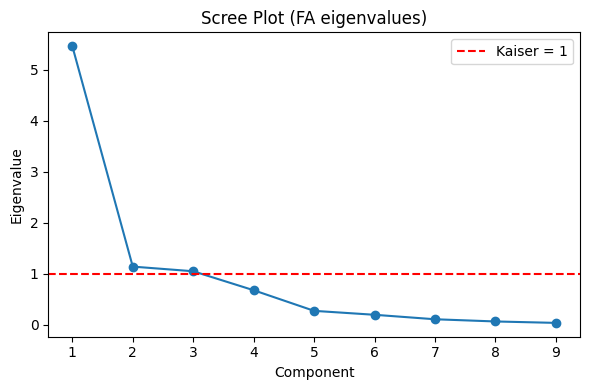

Defaulting to n_factors = 3


In [62]:
# === Determine number of factors (eigenvalues + scree) ===
try:
    from factor_analyzer import FactorAnalyzer
except ImportError:  # fallback for some installs
    from factor_analyzer.factor_analyzer import FactorAnalyzer

fa_tmp = FactorAnalyzer(n_factors=df_clean.shape[1], rotation=None, method='principal')
fa_tmp.fit(df_clean)
ev, v = fa_tmp.get_eigenvalues()

print("Eigenvalues:")
print(np.round(ev, 3))

# Kaiser criterion (eigenvalue > 1)
kaiser_count = int(np.sum(ev > 1))
print(f"\nKaiser suggested factors (>1): {kaiser_count}")

# Scree plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(ev)+1), ev, marker='o')
plt.axhline(1, color='red', linestyle='--', label='Kaiser = 1')
plt.title('Scree Plot (FA eigenvalues)')
plt.xlabel('Component')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(ev)+1))
plt.legend()
plt.tight_layout()
plt.show()

# Pick a default n_factors using Kaiser; you can override based on scree/interpretability
n_factors = max(1, kaiser_count)
print(f"Defaulting to n_factors = {n_factors}")

In [63]:
# === Factor Analysis (varimax) and loadings ===
# If you want to override automatically chosen n_factors, set it here, e.g., n_factors = 3
from pprint import pprint

fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax', method='principal')
fa.fit(df_clean)

# Loadings
loadings = pd.DataFrame(
    fa.loadings_,
    index=df_clean.columns,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

print("Factor loadings (rounded):")
print(loadings.round(3).sort_index())

# Communalities and uniqueness
communalities = pd.Series(fa.get_communalities(), index=df_clean.columns, name='communality')
uniqueness = pd.Series(fa.get_uniquenesses(), index=df_clean.columns, name='uniqueness')
print("\nCommunalities (variance explained by factors):")
print(communalities.round(3).sort_values(ascending=False))
print("\nUniqueness (variance not explained):")
print(uniqueness.round(3).sort_values(ascending=True))

Factor loadings (rounded):
                           Factor1  Factor2  Factor3
fraction_blood_clot          0.828    0.350   -0.097
higher_education_per_1000   -0.977   -0.047    0.066
life_expectancy_years       -0.093   -0.902    0.135
longterm_disease_share       0.850    0.369   -0.063
minimum_physical_activity    0.907    0.092    0.163
morbid_obesity_share         0.950    0.039   -0.001
t2d_patients                -0.048   -0.000    0.947
t2d_prevalence_per_1000      0.902    0.324    0.059
work_absence_rate            0.308    0.618    0.338

Communalities (variance explained by factors):
higher_education_per_1000    0.962
t2d_prevalence_per_1000      0.923
morbid_obesity_share         0.904
t2d_patients                 0.898
longterm_disease_share       0.863
minimum_physical_activity    0.858
life_expectancy_years        0.840
fraction_blood_clot          0.817
work_absence_rate            0.590
Name: communality, dtype: float64

Uniqueness (variance not explained):
higher_e

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [64]:
# === Factor scores and relation to outcome ===
# Compute factor scores
scores = pd.DataFrame(
    fa.transform(df_clean),
    index=df_clean.index,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

# Attach brick metadata and preview
scores_with_meta = pd.concat([
    df.loc[scores.index, ["brick_id", "brick_name"]].reset_index(drop=True),
    scores.reset_index(drop=True)
], axis=1)

print("Scores preview:")
display(scores_with_meta.head())

# Correlate factor scores with T2D prevalence (if available)
if "t2d_prevalence_per_1000" in df.columns:
    y = df.loc[scores.index, "t2d_prevalence_per_1000"].reset_index(drop=True)
    corr_with_outcome = pd.concat([scores.reset_index(drop=True), y.rename("t2d_prevalence_per_1000")], axis=1).corr()["t2d_prevalence_per_1000"].drop("t2d_prevalence_per_1000")
    print("\nCorrelation of factors with T2D prevalence per 1000:")
    print(corr_with_outcome.sort_values(ascending=False).round(3))

# Persist scores for use in regression analysis
scores_with_meta.to_csv("../files/factor_scores.csv", index=False)
print(f"\n✓ Factor scores saved to: ../files/factor_scores.csv")

Scores preview:


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



,brick_id,brick_name,Factor1,Factor2,Factor3
0,101,Bornholm,0.289837,3.850533,-1.697953
1,102,Amager,-1.906182,0.687781,1.311027
2,104,Vesterbro/Christianshavn,-2.590926,0.591486,-0.695341
3,105,Frederiksberg,-2.678030,0.859878,-0.668773
4,106,Glostrup,0.145201,0.870189,2.710003



Correlation of factors with T2D prevalence per 1000:
Factor1    0.902
Factor2    0.324
Factor3    0.059
Name: t2d_prevalence_per_1000, dtype: float64

✓ Factor scores saved to: ../files/factor_scores.csv


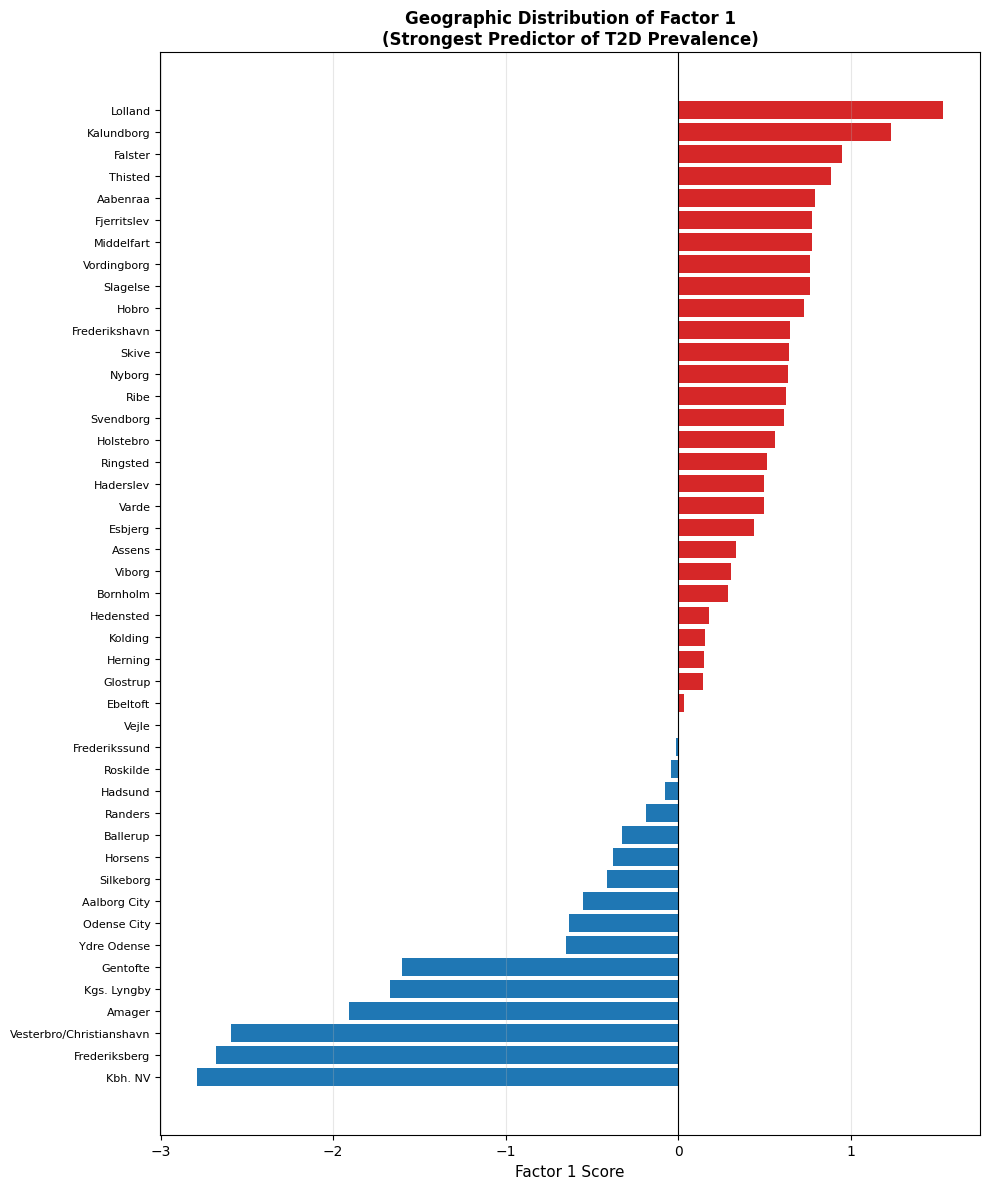


Top 10 areas with HIGHEST Factor 1 scores (highest T2D risk):
 brick_name  Factor1
      Hobro 0.730590
   Slagelse 0.765278
Vordingborg 0.766888
 Middelfart 0.775481
Fjerritslev 0.778588
   Aabenraa 0.792853
    Thisted 0.884290
    Falster 0.949145
 Kalundborg 1.237592
    Lolland 1.534779


Top 10 areas with LOWEST Factor 1 scores (lowest T2D risk):
              brick_name   Factor1
                 Kbh. NV -2.786585
           Frederiksberg -2.678030
Vesterbro/Christianshavn -2.590926
                  Amager -1.906182
             Kgs. Lyngby -1.667883
                Gentofte -1.600203
             Ydre Odense -0.649415
             Odense City -0.633701
            Aalborg City -0.553005
               Silkeborg -0.411659


In [65]:
# === Visualize Factor 1 geographic distribution ===
# Sort by Factor 1 score and create horizontal bar chart
factor1_sorted = scores_with_meta.sort_values('Factor1', ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(range(len(factor1_sorted)), factor1_sorted['Factor1'], 
         color=['#d62728' if x > 0 else '#1f77b4' for x in factor1_sorted['Factor1']])
plt.yticks(range(len(factor1_sorted)), factor1_sorted['brick_name'], fontsize=8)
plt.xlabel('Factor 1 Score', fontsize=11)
plt.title('Geographic Distribution of Factor 1\n(Strongest Predictor of T2D Prevalence)', fontsize=12, fontweight='bold')
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Show top 10 and bottom 10
print("\nTop 10 areas with HIGHEST Factor 1 scores (highest T2D risk):")
print(factor1_sorted[['brick_name', 'Factor1']].tail(10).to_string(index=False))

print("\n\nTop 10 areas with LOWEST Factor 1 scores (lowest T2D risk):")
print(factor1_sorted[['brick_name', 'Factor1']].head(10).to_string(index=False))

In [ ]:
# Display Factor 1 data
factor1_sorted.head()

,brick_id,brick_name,Factor1,Factor2,Factor3
5,107,Kbh. NV,-2.786585,1.048629,-0.528715
3,105,Frederiksberg,-2.678030,0.859878,-0.668773
2,104,Vesterbro/Christianshavn,-2.590926,0.591486,-0.695341
1,102,Amager,-1.906182,0.687781,1.311027
7,110,Kgs. Lyngby,-1.667883,-0.894976,-0.041513
